In [1]:
import numpy as np

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Tanh function
def tanh(x):
    return np.tanh(x)

# Input and previous hidden state
x_t = np.array([[0.8]])
h_prev = np.array([[0.5]])

# Random weights
np.random.seed(42)

Wz = np.random.randn(1,1)
Uz = np.random.randn(1,1)

Wr = np.random.randn(1,1)
Ur = np.random.randn(1,1)

Wh = np.random.randn(1,1)
Uh = np.random.randn(1,1)

bz = np.zeros((1,1))
br = np.zeros((1,1))
bh = np.zeros((1,1))

# Update Gate
z = sigmoid(np.dot(x_t,Wz) + np.dot(h_prev,Uz) + bz)

# Reset Gate
r = sigmoid(np.dot(x_t,Wr) + np.dot(h_prev,Ur) + br)

# Candidate Hidden State
h_candidate = tanh(np.dot(x_t,Wh) + np.dot(r*h_prev,Uh) + bh)

# Final Hidden State
h_t = (1-z)*h_prev + z*h_candidate

print("Update Gate:\n", z)
print("Reset Gate:\n", r)
print("Next Hidden State:\n", h_t)

Update Gate:
 [[0.58133088]]
Reset Gate:
 [[0.78239288]]
Next Hidden State:
 [[0.05126968]]


In [2]:
import pandas as pd

comparison = pd.DataFrame({
    "Feature":[
        "Number of Gates",
        "Cell State",
        "Number of Parameters",
        "Training Speed",
        "Information Flow"
    ],
    "LSTM":[
        "3 (Input, Forget, Output)",
        "Separate Cell State",
        "More",
        "Slower",
        "Uses hidden state + cell state"
    ],
    "GRU":[
        "2 (Update, Reset)",
        "No Separate Cell State",
        "Fewer",
        "Faster",
        "Uses only hidden state"
    ]
})

print(comparison)

                Feature                            LSTM  \
0       Number of Gates       3 (Input, Forget, Output)   
1            Cell State             Separate Cell State   
2  Number of Parameters                            More   
3        Training Speed                          Slower   
4      Information Flow  Uses hidden state + cell state   

                      GRU  
0       2 (Update, Reset)  
1  No Separate Cell State  
2                   Fewer  
3                  Faster  
4  Uses only hidden state  


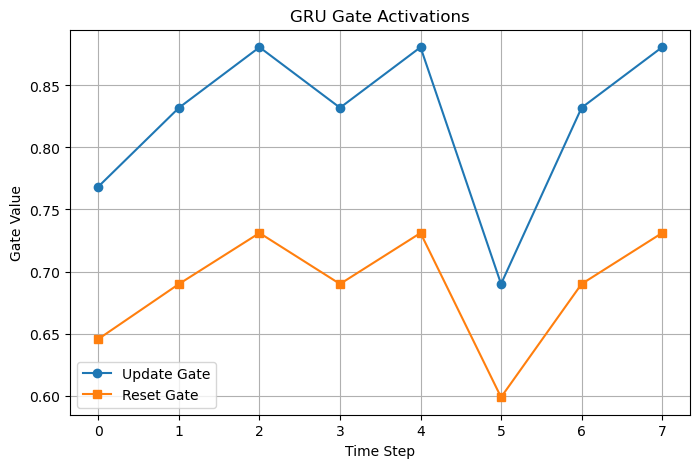

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Spotify song ratings
ratings = np.array([3,4,5,4,5,2,4,5])

update_gate = []
reset_gate = []

np.random.seed(0)

for rating in ratings:

    z = 1/(1+np.exp(-(0.4*rating)))
    r = 1/(1+np.exp(-(0.2*rating)))

    update_gate.append(z)
    reset_gate.append(r)

plt.figure(figsize=(8,5))

plt.plot(update_gate, marker='o', label="Update Gate")
plt.plot(reset_gate, marker='s', label="Reset Gate")

plt.title("GRU Gate Activations")

plt.xlabel("Time Step")

plt.ylabel("Gate Value")

plt.legend()

plt.grid(True)

plt.show()

In [4]:
import numpy as np
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Generate fake daily step counts
steps = np.random.randint(4000,9000,120)

sequence_length = 5

X = []
y = []

for i in range(len(steps)-sequence_length):
    X.append(steps[i:i+sequence_length])
    y.append(steps[i+sequence_length])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0],X.shape[1],1))

# Build GRU model
model = Sequential([
    GRU(32,input_shape=(sequence_length,1)),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

start = time.time()

history = model.fit(
    X,
    y,
    epochs=10,
    verbose=1
)

end = time.time()

print("\nTraining Time:", round(end-start,2),"seconds")

print("Final Loss:", history.history['loss'][-1])

c:\Users\shard\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 43779972.0000
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 43779144.0000
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 43778320.0000
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 43777492.0000
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 43776664.0000
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 43775836.0000
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 43775004.0000
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 43774184.0000
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 43773352.0000
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 43772520.0000

Training Time: 4.03 seconds
Final Loss: 43772520.0
